импортируем библиотеки

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

загрузка данных

In [2]:
dataset = pd.read_csv('pricerunner_aggregate.csv')

определяем размер датасета

In [3]:
dataset.shape

(35311, 7)

демонстрируем первые 10 строк

In [4]:
dataset.head(10)

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
5,6,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,6,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
6,7,apple iphone 8 plus 64 gb space grey,7,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
7,8,apple iphone 8 plus 64gb space grey,8,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
8,9,apple iphone 8 plus 64gb space grey,9,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
9,10,apple iphone 8 plus 64gb space grey,10,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [5]:
import mpl_toolkits.mplot3d


from sklearn import datasets
from sklearn.cluster import KMeans

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product ID       35311 non-null  int64 
 1   Product Title    35311 non-null  object
 2    Merchant ID     35311 non-null  int64 
 3    Cluster ID      35311 non-null  int64 
 4    Cluster Label   35311 non-null  object
 5    Category ID     35311 non-null  int64 
 6    Category Label  35311 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.9+ MB


In [7]:
dataset.describe()

,Product ID,Merchant ID,Cluster ID,Category ID
count,35311.000000,35311.000000,35311.000000,35311.000000
mean,26150.800176,120.501883,30110.687633,2618.142930
std,13498.191220,117.045557,18410.265642,3.600708
min,1.000000,1.000000,1.000000,2612.000000
25%,14958.500000,17.000000,6123.000000,2615.000000
50%,27614.000000,75.000000,40630.000000,2619.000000
75%,37508.500000,253.000000,44059.000000,2622.000000
max,47358.000000,371.000000,47525.000000,2623.000000


берем столбец с наименьшим количеством уникальных значений, перчисляем их

In [9]:
dataset[' Category Label'].unique()

array(['Mobile Phones', 'TVs', 'CPUs', 'Digital Cameras', 'Microwaves',
       'Dishwashers', 'Washing Machines', 'Freezers', 'Fridge Freezers',
       'Fridges'], dtype=object)

проверяем, сколько строк принадлежит каждому классу

In [10]:
dataset[' Category Label'].value_counts()

,count
Category Label,
Fridge Freezers,5501
Mobile Phones,4081
Washing Machines,4044
CPUs,3862
Fridges,3584
TVs,3564
Dishwashers,3424
Digital Cameras,2697
Microwaves,2342


видим, что набор данных несбалансированный, надеемся, что модели и так справятся

визуализируем данные

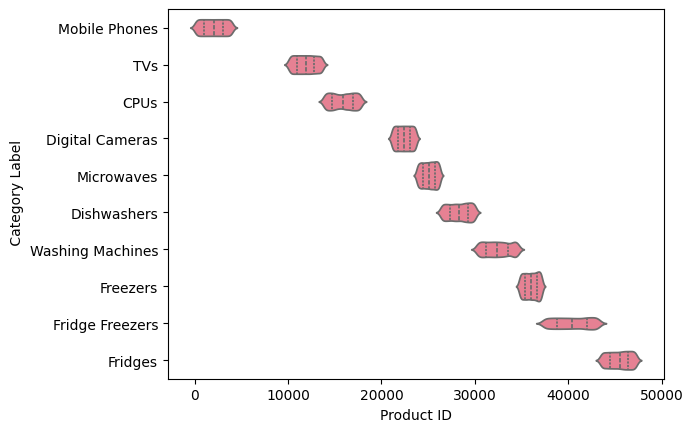

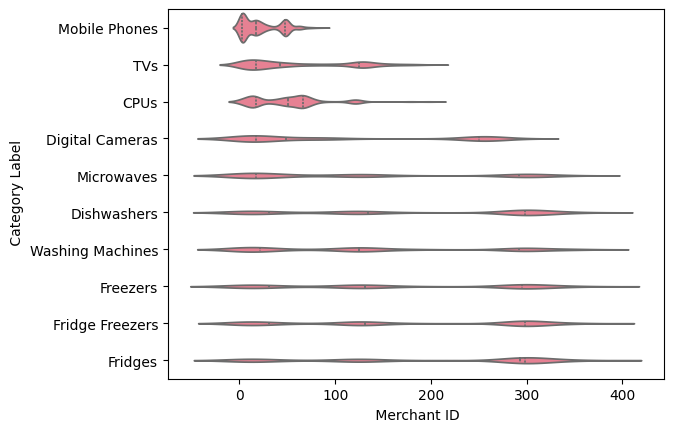

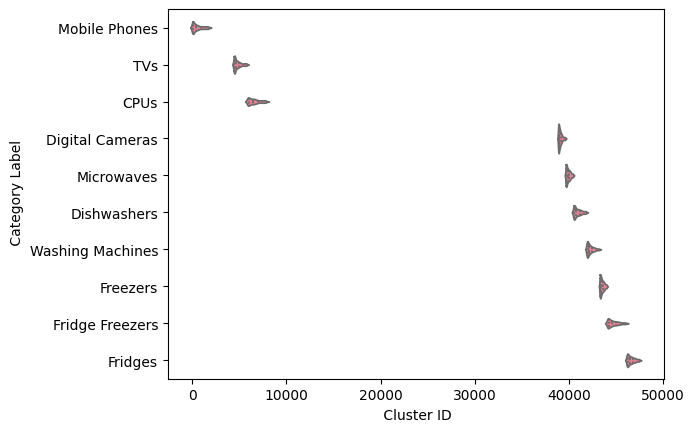

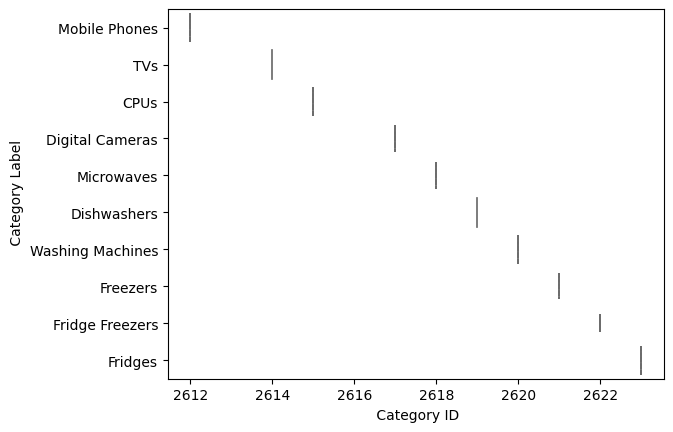

In [12]:
sns.violinplot(y=' Category Label', x='Product ID', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y=' Category Label', x=' Merchant ID', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y=' Category Label', x=' Cluster ID', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y=' Category Label', x=' Category ID', data=dataset, inner='quartile')
plt.show()

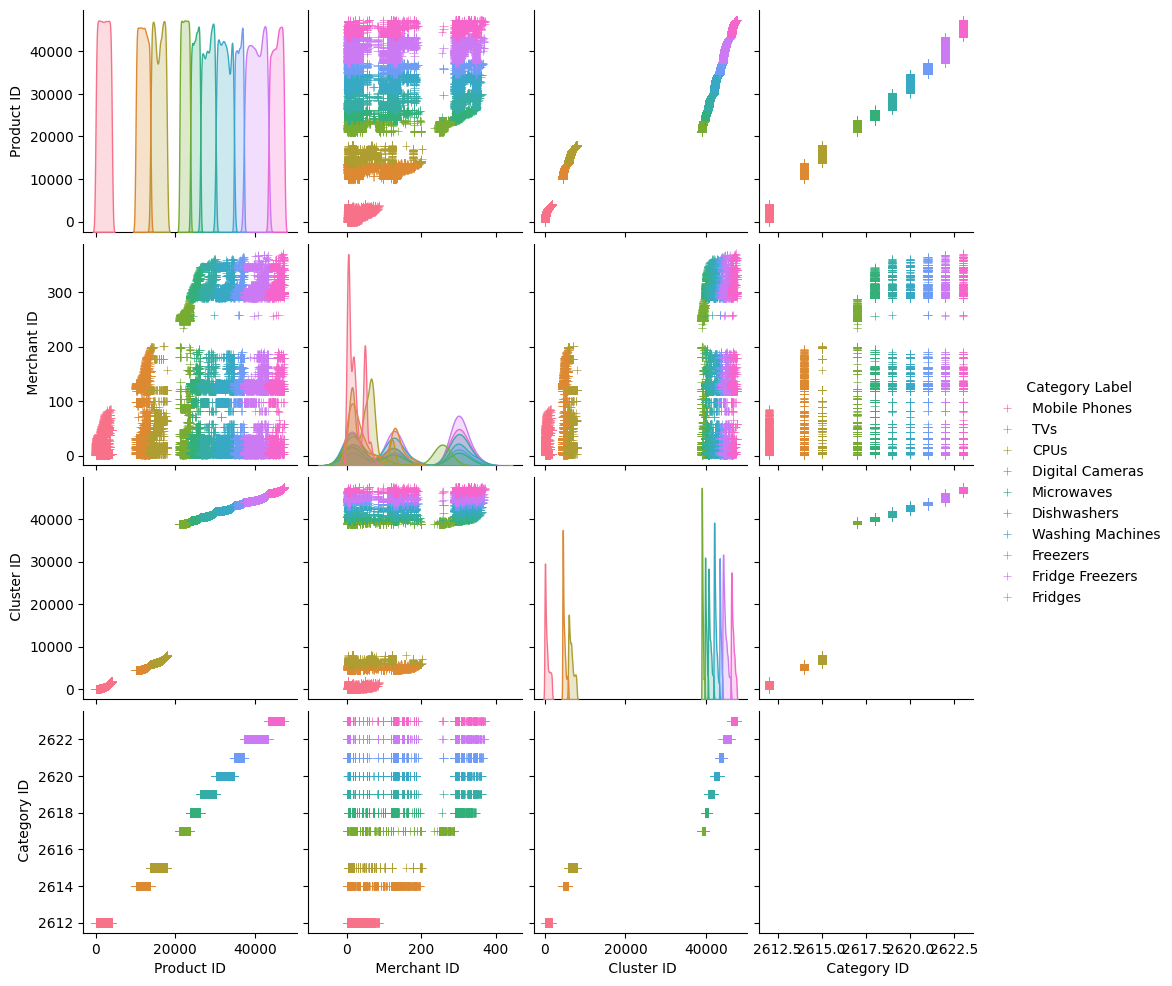

In [13]:
sns.pairplot(dataset, hue=' Category Label', markers='+')
plt.show()

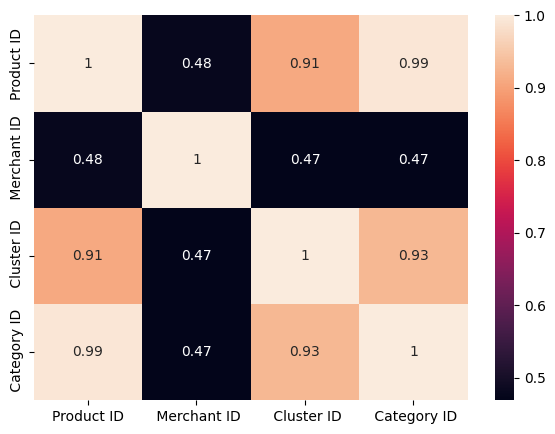

In [14]:
plt.figure(figsize=(7,5))
sns.heatmap(dataset.corr(numeric_only = True), annot=True)
plt.show()

для удобства переведем категориальные признаки в количественные

In [15]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dataset[[' Category Label']] = enc.fit_transform(dataset[[' Category Label']])
dataset[['Product Title']] = enc.fit_transform(dataset[['Product Title']])
dataset[[' Cluster Label']] = enc.fit_transform(dataset[[' Cluster Label']])
dataset.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,2561.0,1,1,909.0,2612,7.0
1,2,2559.0,2,1,909.0,2612,7.0
2,3,2656.0,3,1,909.0,2612,7.0
3,4,2563.0,4,1,909.0,2612,7.0
4,5,2565.0,5,1,909.0,2612,7.0


разделим набор данных на обучающий набор данных и на тестовый, 80% данных пойдет на обучение

In [16]:
X = dataset.drop([' Category Label'], axis=1)
y = dataset[' Category Label']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (35311, 6) | y shape: (35311,) 


используя код из примера, получался бред, поэтому проверяю соотношения классов в выборках в процентах

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
train_distribution = y_train.value_counts(normalize=True).sort_index() * 100
test_distribution = y_test.value_counts(normalize=True).sort_index() * 100
comparison_df = pd.DataFrame({'Train (%)': train_distribution, 'Test (%)': test_distribution})
print(comparison_df)

                 Train (%)   Test (%)
 Category Label                      
0.0              10.935287  10.944358
1.0               7.635939   7.645476
2.0               9.696262   9.698428
3.0               6.265930   6.257964
4.0              15.579864  15.574119
5.0              10.149391  10.151494
6.0               6.634098   6.626080
7.0              11.558340  11.553164
8.0              10.092750  10.094861
9.0              11.452138  11.454056


обучение и выбор оптимальной модели

создаем лист для тех моделей, которые будем изучать

In [25]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

метрики оценить не получилось, поэтому как и в примере возьмем LDA

пришлось поменять solver, потому что с предыдущим значением он не мог продолжить вычисления

In [28]:
sk_lda = LinearDiscriminantAnalysis(solver='svd')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

sk LDA accuracy: 0.94364734755522
sk LDA prediction: [4. 7. 7. ... 8. 6. 1.]
sk transformed features
[[ 6.35842644e+01  6.59349805e+01  6.30594864e+01  6.39301720e+01
   6.44287154e+01]
 [ 5.55192477e+00 -7.21391320e+00  3.83518590e-01  2.26817009e+00
   1.06871754e+01]
 [ 1.33799674e+00  1.41721538e-01  2.76541165e-01  1.38959735e+00
   3.84142441e-01]
 [ 1.83779803e+00  3.90770154e-01 -6.80778511e-01 -9.54296665e-01
   9.64978793e-01]
 [-2.24935197e-01 -7.67259617e-02  2.76777899e+00 -9.44868826e-01
   2.00487694e-02]]


Accuracy 94.36% - это хорошо, но данные у нас были несбалансированные, так что это может быть результатом того, что модель хорошо угадывает большие классы

In [30]:
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition
predicted = sk_lda.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.94
Precision (confidence when predicting a 1): 0.95
Detail:
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      1159
         1.0       0.99      0.98      0.99       809
         2.0       0.95      0.95      0.95      1027
         3.0       0.69      1.00      0.81       664
         4.0       1.00      0.79      0.89      1651
         5.0       0.90      1.00      0.95      1075
         6.0       0.92      0.99      0.96       703
         7.0       1.00      1.00      1.00      1224
         8.0       1.00      0.95      0.97      1069
         9.0       0.99      0.89      0.94      1213

    accuracy                           0.94     10594
   macro avg       0.94      0.96      0.94     10594
weighted avg       0.95      0.94      0.94     10594



Accuracy 94%, но теперь мы видим полную картину. модель отлично справляется с классами 0, 1, 2, 5, 6, 7, 8, хуже - 4, 9, плохо - 3.
класс 4 определяется лучше всех, модель с ним осторожничает - пропускает принадлежащие объекты, не хочет ошибиться. зато с классом 3 нет, она настолько пытается найти объекты, принадлежащие классу, что часто ошибается, однако она нашла все объекты. также по классу 9(самый маленький класс) мы можем видеть, что модель справилась с дисбалансом данных

попробуем другие модели

LR

In [54]:
sk_lr = LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial')
sk_lr.fit(X_train, y_train)
sk_lr_pred = sk_lr.predict(X_test)
sk_lr_accuracy = accuracy_score(y_test, sk_lr_pred)
print(f"accuracy: {sk_lr_accuracy}")
print(f"prediction: {sk_lr_pred}")

accuracy: 1.0
prediction: [4. 7. 7. ... 8. 6. 1.]


In [32]:
predicted = sk_lr.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.99
Precision (confidence when predicting a 1): 0.99
Detail:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1159
         1.0       1.00      1.00      1.00       809
         2.0       0.98      0.99      0.98      1027
         3.0       0.98      0.95      0.97       664
         4.0       0.98      0.99      0.99      1651
         5.0       1.00      0.98      0.99      1075
         6.0       0.98      0.98      0.98       703
         7.0       1.00      1.00      1.00      1224
         8.0       1.00      1.00      1.00      1069
         9.0       0.98      0.99      0.99      1213

    accuracy                           0.99     10594
   macro avg       0.99      0.99      0.99     10594
weighted avg       0.99      0.99      0.99     10594



в итоге эта модель справилась лучше предыдущей, даже реабилитировала 3 и 4 классы

KNN

In [55]:
for k in [3, 4, 5, 6, 7, 8, 9]:
    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train, y_train)
    sk_knn_pred = sk_knn.predict(X_test)
    sk_knn_accuracy = accuracy_score(y_test, sk_knn_pred)
    print(f"KNN (k={k}) accuracy: {sk_knn_accuracy}")

KNN (k=3) accuracy: 0.9965074570511611
KNN (k=4) accuracy: 0.9951859543137626
KNN (k=5) accuracy: 0.9951859543137626
KNN (k=6) accuracy: 0.9950915612610912
KNN (k=7) accuracy: 0.9947139890504059
KNN (k=8) accuracy: 0.9947139890504059
KNN (k=9) accuracy: 0.9938644515763639


In [41]:
sk_knn = KNeighborsClassifier(n_neighbors=4)
sk_knn.fit(X_train, y_train)
sk_knn_pred = sk_knn.predict(X_test)
sk_knn_accuracy = accuracy_score(y_test, sk_knn_pred)
print(f"\nИтоговый KNN (k=4) accuracy: {sk_knn_accuracy}")


Итоговый KNN (k=4) accuracy: 0.9953747404191051


In [42]:
predicted = sk_knn.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 1.0
Precision (confidence when predicting a 1): 1.0
Detail:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1159
         1.0       1.00      1.00      1.00       809
         2.0       0.99      1.00      0.99      1027
         3.0       0.99      0.99      0.99       664
         4.0       1.00      0.99      1.00      1651
         5.0       0.99      1.00      1.00      1075
         6.0       0.99      0.98      0.99       703
         7.0       1.00      1.00      1.00      1224
         8.0       1.00      1.00      1.00      1069
         9.0       1.00      0.99      0.99      1213

    accuracy                           1.00     10594
   macro avg       0.99      0.99      0.99     10594
weighted avg       1.00      1.00      1.00     10594



с каждым разом модели все точнее и точнее, есть ощущение, что они переобучаются

деревья

In [56]:
sk_tree = DecisionTreeClassifier(random_state=42)
sk_tree.fit(X_train, y_train)
sk_tree_pred = sk_tree.predict(X_test)
sk_tree_accuracy = accuracy_score(y_test, sk_tree_pred)
print(f"accuracy: {sk_tree_accuracy}")

accuracy: 1.0


In [45]:
predicted = sk_tree.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 1.0
Precision (confidence when predicting a 1): 1.0
Detail:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1159
         1.0       1.00      1.00      1.00       809
         2.0       1.00      1.00      1.00      1027
         3.0       1.00      1.00      1.00       664
         4.0       1.00      1.00      1.00      1651
         5.0       1.00      1.00      1.00      1075
         6.0       1.00      1.00      1.00       703
         7.0       1.00      1.00      1.00      1224
         8.0       1.00      1.00      1.00      1069
         9.0       1.00      1.00      1.00      1213

    accuracy                           1.00     10594
   macro avg       1.00      1.00      1.00     10594
weighted avg       1.00      1.00      1.00     10594



и снова идеально, очень подозрительно

метод векторов

In [44]:
sk_svc = SVC(gamma='auto', decision_function_shape='ovo')
sk_svc.fit(X_train, y_train)
sk_svc_pred = sk_svc.predict(X_test)
sk_svc_accuracy = accuracy_score(y_test, sk_svc_pred)
print(f"accuracy: {sk_svc_accuracy}")

accuracy: 0.2021899188219747


In [46]:
predicted = sk_svc.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.2
Precision (confidence when predicting a 1): 0.87
Detail:
              precision    recall  f1-score   support

         0.0       1.00      0.11      0.19      1159
         1.0       1.00      0.02      0.03       809
         2.0       1.00      0.05      0.09      1027
         3.0       1.00      0.03      0.07       664
         4.0       0.16      1.00      0.28      1651
         5.0       1.00      0.06      0.11      1075
         6.0       1.00      0.03      0.05       703
         7.0       1.00      0.11      0.19      1224
         8.0       1.00      0.02      0.05      1069
         9.0       1.00      0.04      0.07      1213

    accuracy                           0.20     10594
   macro avg       0.92      0.15      0.11     10594
weighted avg       0.87      0.20      0.13     10594



модель вообще не справилась с задачей, на самом деле радует после 4 идеальных моделей, благодаря этому можно что-то сказать и про предыдущие модели. эта модель пыталась разделить классы между собой, но у нее плохо получилось, остальные модели, видимо, переобучились.
я бы доверилась самой первой модели LDA

на основе своих данных получила такой график для LR

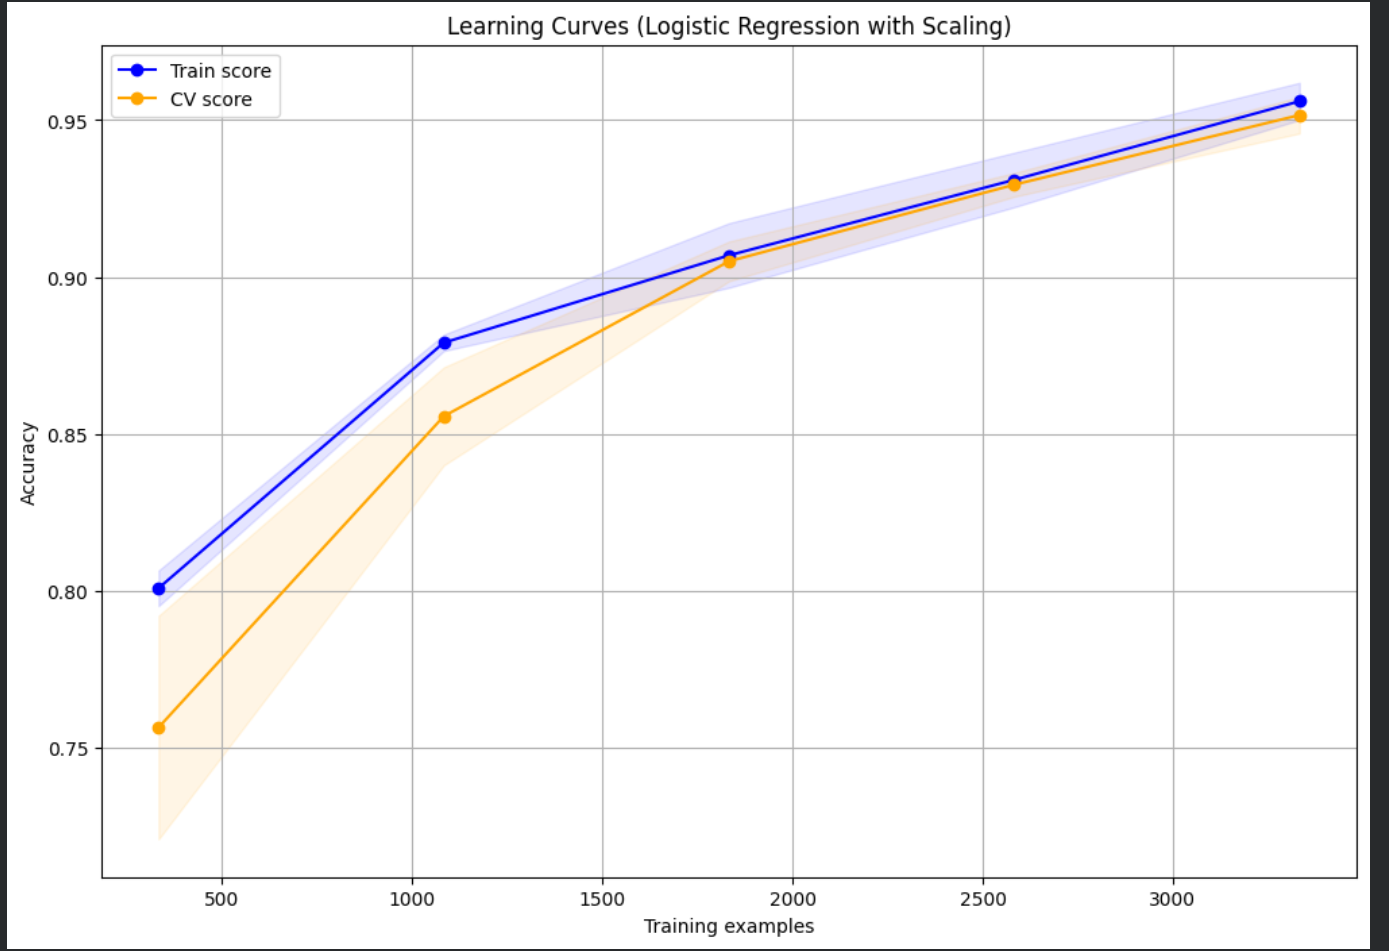

последнее предположение - проблема в столбце Category ID, это же буквально Category Label, только в числовом варианте, удалим его

In [73]:
print(X_train.columns.tolist())

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID']


In [71]:
columns_to_drop = [' Category ID']

In [74]:
X_train_clean = X_train.drop(columns=columns_to_drop)
X_test_clean = X_test.drop(columns=columns_to_drop)
print(X_train_clean.columns.tolist())

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label']


In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

проверяем модели после удаления столбца

In [76]:
sk_lda = LinearDiscriminantAnalysis(solver='svd')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

sk LDA accuracy: 0.9422341781112842
sk LDA prediction: [4. 2. 8. ... 5. 9. 2.]
sk transformed features
[[ 6.32825384e+01  6.71057158e+01 -1.32274659e+02 -1.28781249e+02
   6.34305026e+01]
 [ 5.46806998e-01 -7.79846248e+00 -2.03171127e+00 -2.91614576e+00
   4.00312685e+00]
 [-1.17036374e+00  4.65930054e-02  8.95196380e-01  9.07377531e-01
   1.06890920e+00]
 [ 1.07986446e+00  1.77928948e+00  5.67021932e-01  1.77584097e-01
   6.09095920e-01]
 [ 7.45231441e-01  3.12012678e-01 -3.84375934e-01 -4.86105733e-01
  -2.83877958e-01]]


In [77]:
sk_lr = LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial')
sk_lr.fit(X_train, y_train)
sk_lr_pred = sk_lr.predict(X_test)
sk_lr_accuracy = accuracy_score(y_test, sk_lr_pred)
print(f"accuracy: {sk_lr_accuracy}")
print(f"prediction: {sk_lr_pred}")

accuracy: 0.9859832932181792
prediction: [4. 2. 8. ... 5. 9. 2.]


у первых двух процент чуть-чуть упал

In [80]:
for k in [3, 4, 5, 6, 7, 8, 9]:
    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train, y_train)
    sk_knn_pred = sk_knn.predict(X_test)
    sk_knn_accuracy = accuracy_score(y_test, sk_knn_pred)
    print(f"KNN (k={k}) accuracy: {sk_knn_accuracy}")

KNN (k=3) accuracy: 0.9960356788899901
KNN (k=4) accuracy: 0.9961772617867761
KNN (k=5) accuracy: 0.995894095993204
KNN (k=6) accuracy: 0.9950445986124876
KNN (k=7) accuracy: 0.9947614328189155
KNN (k=8) accuracy: 0.993770352541413
KNN (k=9) accuracy: 0.9934871867478409


In [81]:
sk_tree = DecisionTreeClassifier(random_state=42)
sk_tree.fit(X_train, y_train)
sk_tree_pred = sk_tree.predict(X_test)
sk_tree_accuracy = accuracy_score(y_test, sk_tree_pred)
print(f"accuracy: {sk_tree_accuracy}")

accuracy: 1.0


In [82]:
sk_svc = SVC(gamma='auto', decision_function_shape='ovo')
sk_svc.fit(X_train, y_train)
sk_svc_pred = sk_svc.predict(X_test)
sk_svc_accuracy = accuracy_score(y_test, sk_svc_pred)
print(f"accuracy: {sk_svc_accuracy}")

accuracy: 0.20671102930765964


ладно, я не могу придумать причину, почему они переобучились, данные были плохо подготовлены, зато методы попробовала